# Avaliação visual do pipeline em bancos CCTA externos

Esta análise resume a inspeção visual dos resultados do pipeline no **MM-WHS** e no **OrCaScore**. As classificações descrevem a aparência dos artefatos produzidos e não constituem validação clínica.

Os percentuais usam todos os exames avaliados como denominador, inclusive os classificados como `Não avaliável`.

In [1]:
# ruff: noqa: E402
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").is_file()
)
sys.path.insert(0, str(REPO_ROOT / "src"))

from utils.project.external_visual_assessment import (
    AORTA_ARTERY_STATUS_ORDER,
    OSTIA_STATUS_ORDER,
    load_external_visual_assessments,
    summarize_visual_status,
)

pd.set_option("display.max_columns", 30)
plt.style.use("seaborn-v0_8-whitegrid")

## Configuração e carregamento

In [2]:
EXTERNAL_RESULTS_ROOT = Path(
    os.environ.get(
        "EXTERNAL_CCTA_RESULTS_ROOT",
        "/media/matheus/HD/Results_dataset_ccta",
    )
)
VISUAL_ASSESSMENT_PATHS = {
    "MM-WHS": EXTERNAL_RESULTS_ROOT
    / "mmwhs/mid_res/2026-09-19_10-23-15/visual/avaliacao_visual.xlsx",
    "OrCaScore": EXTERNAL_RESULTS_ROOT
    / "orcascore/mid_res/2026-09-19_10-23-50/visual/avaliacao_visual.xlsx",
}

DATASET_ORDER = ["MM-WHS", "OrCaScore"]
COHORT_ORDER = [*DATASET_ORDER, "Geral"]
STATUS_COLORS = {
    "Adequada": "#22C55E",
    "Ambos adequados": "#22C55E",
    "Parcial": "#EAB308",
    "Um adequado": "#EAB308",
    "Inadequada": "#EF4444",
    "Inadequados": "#EF4444",
    "Não detectada": "#F97316",
    "Não detectados": "#F97316",
    "Não avaliável": "#9CA3AF",
}

assessments = load_external_visual_assessments(VISUAL_ASSESSMENT_PATHS)
print(f"Avaliações carregadas: {len(assessments)}")
display(assessments.groupby("dataset").size().rename("exames").to_frame())

Avaliações carregadas: 132


,exames
dataset,
MM-WHS,60
OrCaScore,72


In [3]:
def cohort_frame(dataset):
    if dataset == "Geral":
        return assessments
    return assessments.loc[assessments["dataset"].eq(dataset)]


def show_stage_results(column, status_order, title):
    summary = summarize_visual_status(
        assessments,
        column,
        status_order,
        DATASET_ORDER,
    )
    compact = summary.assign(
        resultado=summary.apply(
            lambda row: f"{row['count']} ({row['percent']:.1f}%)", axis=1
        )
    ).pivot(index="dataset", columns="status", values="resultado")
    display(compact.reindex(index=COHORT_ORDER, columns=status_order))

    percentages = summary.pivot(
        index="dataset", columns="status", values="percent"
    ).reindex(index=COHORT_ORDER, columns=status_order)
    fig, ax = plt.subplots(figsize=(10, 3.8))
    left = np.zeros(len(percentages))
    for status in status_order:
        values = percentages[status].to_numpy()
        bars = ax.barh(
            percentages.index,
            values,
            left=left,
            color=STATUS_COLORS[status],
            label=status,
        )
        for bar, value in zip(bars, values, strict=True):
            if value >= 5:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                )
        left += values
    ax.set(xlabel="Exames (%)", ylabel="", title=title, xlim=(0, 100))
    ax.invert_yaxis()
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False)
    plt.show()
    return summary

## 1. Resultados gerais

,Exames,Aorta (n),Aorta (%),Óstios (n),Óstios (%),Artéria (n),Artéria (%),Com observação (n),Com observação (%)
Banco,,,,,,,,,
MM-WHS,60,37,61.7,28,46.7,15,25.0,0,0.0
OrCaScore,72,45,62.5,33,45.8,21,29.2,17,23.6
Geral,132,82,62.1,61,46.2,36,27.3,17,12.9


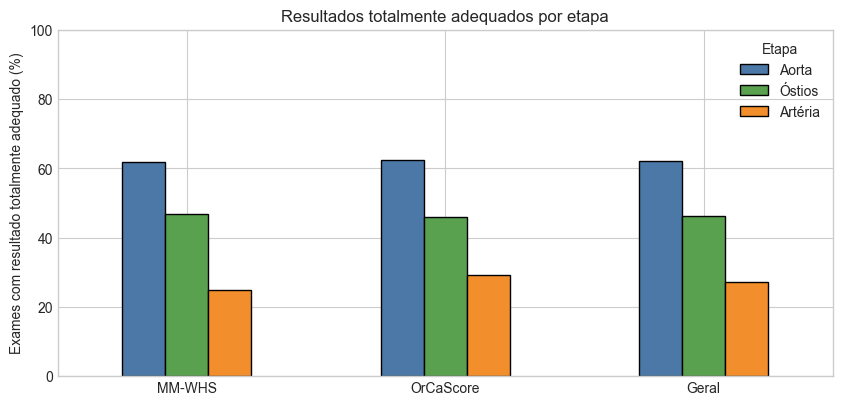

In [4]:
fully_adequate = {
    "Aorta": ("aorta_result", "Adequada"),
    "Óstios": ("ostia_result", "Ambos adequados"),
    "Artéria": ("artery_result", "Adequada"),
}
general_rows = []
for dataset in COHORT_ORDER:
    cohort = cohort_frame(dataset)
    row = {"Banco": dataset, "Exames": len(cohort)}
    for stage, (column, adequate_status) in fully_adequate.items():
        adequate_count = int(cohort[column].eq(adequate_status).sum())
        row[f"{stage} (n)"] = adequate_count
        row[f"{stage} (%)"] = 100 * adequate_count / len(cohort)
    note_count = int(cohort["visual_assessment_notes"].ne("").sum())
    row["Com observação (n)"] = note_count
    row["Com observação (%)"] = 100 * note_count / len(cohort)
    general_rows.append(row)

general_summary = pd.DataFrame(general_rows).set_index("Banco")
display(general_summary.round(1))

adequate_rates = general_summary[[f"{stage} (%)" for stage in fully_adequate]].rename(
    columns=lambda column: column.removesuffix(" (%)")
)
ax = adequate_rates.plot(
    kind="bar",
    figsize=(10, 4.5),
    color=["#4C78A8", "#59A14F", "#F28E2B"],
    edgecolor="black",
    rot=0,
)
ax.set(
    xlabel="",
    ylabel="Exames com resultado totalmente adequado (%)",
    ylim=(0, 100),
    title="Resultados totalmente adequados por etapa",
)
ax.legend(title="Etapa", frameon=False)
plt.show()

### Observações registradas

In [5]:
observed = assessments.loc[assessments["visual_assessment_notes"].ne("")]
if observed.empty:
    print("Nenhuma observação visual foi registrada.")
else:
    observation_summary = (
        observed.groupby(["dataset", "visual_assessment_notes"])
        .size()
        .rename("count")
        .reset_index()
    )
    dataset_sizes = assessments.groupby("dataset").size()
    observation_summary["percent_of_dataset"] = observation_summary.apply(
        lambda row: 100 * row["count"] / dataset_sizes[row["dataset"]],
        axis=1,
    )
    display(observation_summary.round({"percent_of_dataset": 1}))

,dataset,visual_assessment_notes,count,percent_of_dataset
0,OrCaScore,Achatado,17,23.6


Os dois bancos apresentam proporções próximas de aortas e pares de óstios totalmente adequados. A artéria é a etapa com menor frequência de resultados totalmente adequados. A observação `Achatado` aparece somente no OrCaScore e descreve a visualização, não uma categoria de qualidade da segmentação.

## 2. Aorta

status,Adequada,Parcial,Inadequada,Não detectada,Não avaliável
dataset,,,,,
MM-WHS,37 (61.7%),8 (13.3%),9 (15.0%),6 (10.0%),0 (0.0%)
OrCaScore,45 (62.5%),9 (12.5%),5 (6.9%),9 (12.5%),4 (5.6%)
Geral,82 (62.1%),17 (12.9%),14 (10.6%),15 (11.4%),4 (3.0%)


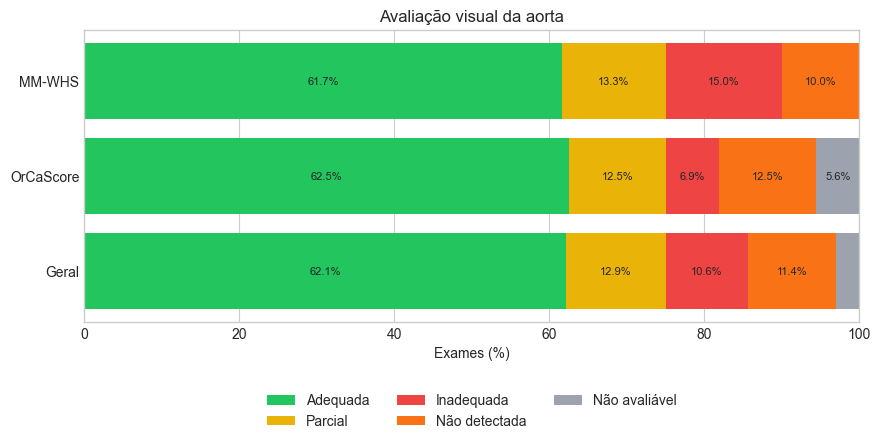

In [6]:
aorta_summary = show_stage_results(
    "aorta_result",
    AORTA_ARTERY_STATUS_ORDER,
    "Avaliação visual da aorta",
)

A proporção de aortas adequadas é semelhante nos dois bancos: aproximadamente 62%. Os casos restantes se distribuem entre resultados parciais, inadequados, não detectados e, no OrCaScore, não avaliáveis.

## 3. Óstios

status,Ambos adequados,Um adequado,Inadequados,Não detectados,Não avaliável
dataset,,,,,
MM-WHS,28 (46.7%),9 (15.0%),16 (26.7%),0 (0.0%),7 (11.7%)
OrCaScore,33 (45.8%),9 (12.5%),6 (8.3%),0 (0.0%),24 (33.3%)
Geral,61 (46.2%),18 (13.6%),22 (16.7%),0 (0.0%),31 (23.5%)


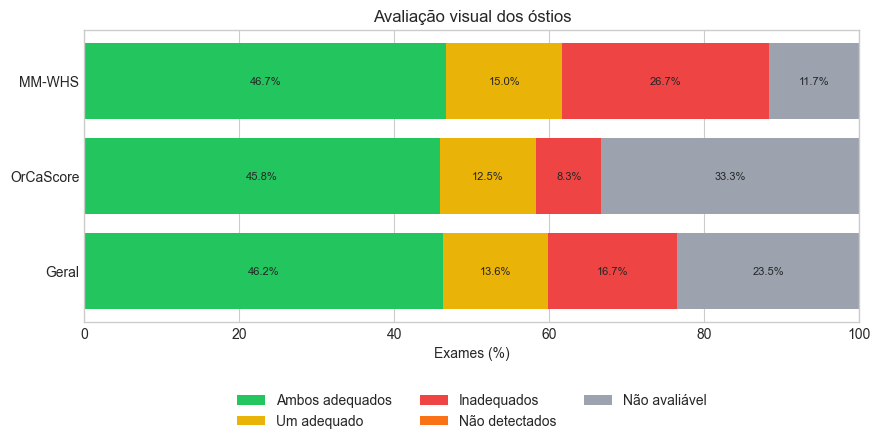

In [7]:
ostia_summary = show_stage_results(
    "ostia_result",
    OSTIA_STATUS_ORDER,
    "Avaliação visual dos óstios",
)

Cerca de 46% dos exames apresentam ambos os óstios adequados nos dois bancos. O OrCaScore possui uma proporção maior de exames não avaliáveis, enquanto o MM-WHS concentra mais resultados inadequados.

## 4. Artéria

status,Adequada,Parcial,Inadequada,Não detectada,Não avaliável
dataset,,,,,
MM-WHS,15 (25.0%),20 (33.3%),16 (26.7%),2 (3.3%),7 (11.7%)
OrCaScore,21 (29.2%),20 (27.8%),5 (6.9%),3 (4.2%),23 (31.9%)
Geral,36 (27.3%),40 (30.3%),21 (15.9%),5 (3.8%),30 (22.7%)


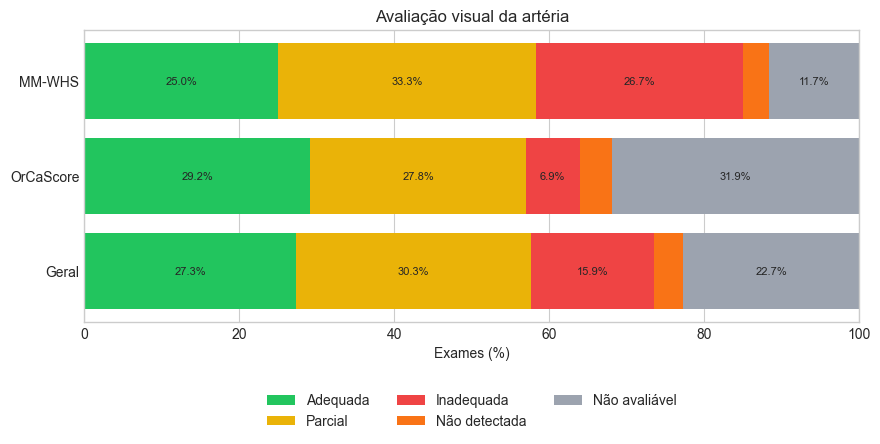

In [8]:
artery_summary = show_stage_results(
    "artery_result",
    AORTA_ARTERY_STATUS_ORDER,
    "Avaliação visual da artéria",
)

A artéria apresenta a menor proporção de resultados totalmente adequados: 25,0% no MM-WHS e 29,2% no OrCaScore. Resultados parciais são frequentes nos dois bancos; o MM-WHS possui mais resultados inadequados e o OrCaScore, mais casos não avaliáveis.